# LSTM composer classifier

Reads the note sequences from `02_parse_midi_lstm` and the splits from `04_split_and_augment`, trains an LSTM, and evaluates on the test set.

Input/output shapes are defined in `docs/interface-contract.md`. Test set is touched exactly once, at the bottom.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

LSTM_DIR = Path("../data/processed/lstm")
SPLIT_DIR = Path("../data/splits")
MODEL_DIR = Path("../models")
RESULTS_DIR = Path("../results")
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

COMPOSERS = ["bach", "beethoven", "chopin", "mozart"]
LABEL = {c: i for i, c in enumerate(COMPOSERS)}

MAX_NOTES = 500   # pieces run to 40k+ notes; we read the opening 500
EPOCHS = 100
BATCH = 32
LR = 5e-4
CLIPNORM = 1.0
PATIENCE = 12

print(tf.__version__)

2.21.0


## Load the sequences

Each `.npz` has four parallel arrays: pitch, duration, velocity, offset.

Pitch is kept as an **integer** and fed through an `Embedding` rather than scaled to [0, 1]. Pitch is categorical, not ordinal — MIDI 60 is not "half of" MIDI 120, and the intervals that define a composer's harmonic language are relationships between pitch classes, not magnitudes. The first version of this notebook scaled pitch as a plain float and badly underfit (train accuracy 0.43 and still rising when training stopped, test accuracy 0.366 against a 0.626 majority-class baseline).

The other three features are genuinely continuous and are scaled. `offset` (absolute time) becomes the gap since the previous note, which is what actually carries rhythm.

In [2]:
def load_sequence(composer, filename):
    """npz -> (pitch int32 (MAX_NOTES,), continuous float32 (MAX_NOTES, 3)).

    Pitch 0 marks padding, which is what the Embedding masks on.
    Continuous columns: duration, velocity, inter-onset gap.
    """
    z = np.load(LSTM_DIR / composer / (Path(filename).stem + ".npz"))
    n = min(len(z["pitch"]), MAX_NOTES)
    pitch = np.zeros(MAX_NOTES, dtype=np.int32)
    cont = np.zeros((MAX_NOTES, 3), dtype=np.float32)
    if n:
        off = z["offset"][:n]
        pitch[:n] = z["pitch"][:n]
        cont[:n, 0] = np.clip(z["duration"][:n], 0, 4) / 4.0
        cont[:n, 1] = z["velocity"][:n] / 127.0
        cont[:n, 2] = np.clip(np.diff(off, prepend=off[0]), 0, 4) / 4.0
    return pitch, cont


def load_split(name):
    df = pd.read_csv(SPLIT_DIR / f"{name}.csv")
    loaded = [load_sequence(r.composer, r.filename) for r in df.itertuples()]
    X = [np.stack([p for p, _ in loaded]), np.stack([c for _, c in loaded])]
    y = df["composer"].map(LABEL).to_numpy()
    return X, y, df


X_train, y_train, train_df = load_split("train")
X_val, y_val, _ = load_split("val")
X_test, y_test, _ = load_split("test")

print("train pitch", X_train[0].shape, "cont", X_train[1].shape)
print("val", X_val[0].shape[0], "test", X_test[0].shape[0])
print("train labels", np.bincount(y_train))
print("test labels ", np.bincount(y_test))

train pitch (2188, 500) cont (2188, 500, 3)
val 245 test 246
train labels [717 459 475 537]
test labels  [154  33  20  39]


In [3]:
# Class weights come from the UNaugmented train counts. The augmented rows already
# do some of the rebalancing; weighting on the post-augmentation counts would
# double-count that correction.
orig = train_df.loc[~train_df["is_augmented"], "composer"].map(LABEL).to_numpy()
weights = compute_class_weight("balanced", classes=np.arange(4), y=orig)
class_weight = dict(enumerate(weights))

pd.DataFrame({
    "composer": COMPOSERS,
    "train_original": np.bincount(orig, minlength=4),
    "train_augmented": np.bincount(y_train, minlength=4),
    "class_weight": weights.round(3),
})

,composer,train_original,train_augmented,class_weight
0,bach,717,717,0.399
1,beethoven,153,459,1.869
2,chopin,95,475,3.011
3,mozart,179,537,1.598


## Model

Pitch goes through a 16-dimensional embedding and is concatenated with the three continuous features, then two stacked LSTM layers. `mask_zero=True` on the embedding propagates through the concatenate, so the zero-padded tail is skipped and short pieces aren't penalised for being short.

**Gradient clipping is load-bearing.** Without `clipnorm`, this model trained normally for five epochs (loss 1.99 → 1.77, val loss 1.74 → 1.46) and then blew up: loss jumped to 2.03 and training accuracy froze at 0.22 for the remaining epochs, i.e. the weights were destroyed by one bad update and never recovered. Backpropagating through 500 time steps makes that failure easy to hit. `clipnorm=1.0` plus a halved learning rate and `ReduceLROnPlateau` is the standard remedy.

In [4]:
pitch_in = tf.keras.layers.Input((MAX_NOTES,), dtype="int32", name="pitch")
cont_in = tf.keras.layers.Input((MAX_NOTES, 3), name="continuous")

e = tf.keras.layers.Embedding(128, 16, mask_zero=True)(pitch_in)
x = tf.keras.layers.Concatenate()([e, cont_in])
x = tf.keras.layers.LSTM(128, return_sequences=True)(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.LSTM(64)(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model([pitch_in, cont_in], outputs, name="lstm_composer")
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR, clipnorm=CLIPNORM),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "lstm_composer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pitch (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 16)   │      2,048 │ pitch[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 500)       │          0 │ pitch[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuous          │ (None, 500, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 500, 1)    │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 500, 16)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 500, 16)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 500, 3)    │          0 │ continuous[0][0]  │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 500, 19)   │          0 │ logical_or[0][0], │
│ (Concatenate)       │                   │            │ ones_like[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 19)   │          0 │ embedding[0][0],  │
│ (Concatenate)       │                   │            │ continuous[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 500)       │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 500, 128)  │     75,776 │ concatenate[0][0… │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 500, 128)  │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,492 (498.02 KB)

 Trainable params: 127,492 (498.02 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=PATIENCE, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)

model.save(MODEL_DIR / "lstm.keras")

Epoch 1/100


69/69 - 12s - 178ms/step - accuracy: 0.2281 - loss: 2.0040 - val_accuracy: 0.3592 - val_loss: 1.8065 - learning_rate: 5.0000e-04


Epoch 2/100


69/69 - 11s - 156ms/step - accuracy: 0.2719 - loss: 1.9505 - val_accuracy: 0.1061 - val_loss: 1.8012 - learning_rate: 5.0000e-04


Epoch 3/100


...

69/69 - 10s - 150ms/step - accuracy: 0.5279 - loss: 1.5369 - val_accuracy: 0.4694 - val_loss: 1.4378 - learning_rate: 6.2500e-05


Epoch 26/100


69/69 - 10s - 151ms/step - accuracy: 0.5274 - loss: 1.5234 - val_accuracy: 0.4653 - val_loss: 1.4330 - learning_rate: 3.1250e-05


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 14.


In [6]:
# Guard against the failure modes seen while building this: collapsing to a single
# class, and diverging mid-training (loss rising off a plateau and never recovering).
val_pred = model.predict(X_val, verbose=0).argmax(axis=1)
losses = history.history["loss"]
print("val predictions per class:", dict(zip(COMPOSERS, np.bincount(val_pred, minlength=4))))
print("final train accuracy:", round(history.history["accuracy"][-1], 3))
print("best / final train loss:", round(min(losses), 3), "/", round(losses[-1], 3))
assert len(np.unique(val_pred)) > 1, "model collapsed to one class on validation"
assert losses[-1] < min(losses) + 0.15, "training diverged: final loss well above its best"
print("val accuracy:", (val_pred == y_val).mean().round(3))

val predictions per class: {'bach': np.int64(113), 'beethoven': np.int64(4), 'chopin': np.int64(52), 'mozart': np.int64(76)}
final train accuracy: 0.527
best / final train loss: 1.523 / 1.523
val accuracy: 0.522


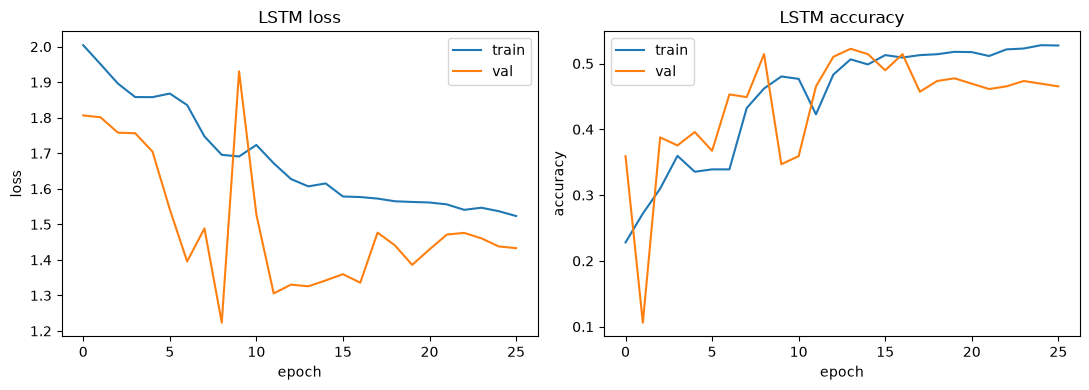

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set(title="LSTM loss", xlabel="epoch", ylabel="loss")
ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set(title="LSTM accuracy", xlabel="epoch", ylabel="accuracy")
ax[1].legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "history_lstm.png", dpi=120)
plt.show()

## Test set evaluation

First and only look at the test set. Note the majority-class baseline: bach is 63% of the test set, so accuracy below that is worse than always guessing bach. Macro precision/recall is the honest number.

In [8]:
def evaluate(model, X, y, name):
    """Score on the test set, write results/<name>_metrics.json, return the dict."""
    y_pred = model.predict(X, verbose=0).argmax(axis=1)
    p_mac, r_mac, _, _ = precision_recall_fscore_support(
        y, y_pred, average="macro", zero_division=0)
    p_w, r_w, _, _ = precision_recall_fscore_support(
        y, y_pred, average="weighted", zero_division=0)
    p, r, f1, sup = precision_recall_fscore_support(
        y, y_pred, labels=range(4), zero_division=0)

    metrics = {
        "model": name,
        "accuracy": float((y_pred == y).mean()),
        "precision_macro": float(p_mac),
        "recall_macro": float(r_mac),
        "precision_weighted": float(p_w),
        "recall_weighted": float(r_w),
        "per_class": {
            c: {"precision": float(p[i]), "recall": float(r[i]),
                "f1": float(f1[i]), "support": int(sup[i])}
            for i, c in enumerate(COMPOSERS)
        },
        "confusion_matrix": confusion_matrix(y, y_pred, labels=range(4)).tolist(),
        "history": {k: [float(v) for v in vs] for k, vs in history.history.items()},
        "params": {"max_notes": MAX_NOTES, "epochs_run": len(history.history["loss"]),
                   "max_epochs": EPOCHS, "batch": BATCH, "lr": LR,
                   "clipnorm": CLIPNORM, "patience": PATIENCE, "seed": SEED},
    }
    (RESULTS_DIR / f"{name}_metrics.json").write_text(json.dumps(metrics, indent=2))
    print(classification_report(y, y_pred, target_names=COMPOSERS, zero_division=0))
    print(f"majority-class baseline: {np.bincount(y).max() / len(y):.3f}")
    return metrics


metrics = evaluate(model, X_test, y_test, "lstm")
metrics["accuracy"], metrics["precision_macro"], metrics["recall_macro"]

              precision    recall  f1-score   support

        bach       0.78      0.58      0.67       154
   beethoven       0.60      0.09      0.16        33
      chopin       0.26      0.70      0.38        20
      mozart       0.21      0.38      0.27        39

    accuracy                           0.50       246
   macro avg       0.46      0.44      0.37       246
weighted avg       0.62      0.50      0.51       246

majority-class baseline: 0.626


(0.4959349593495935, 0.4625503220611916, 0.43998501498501497)

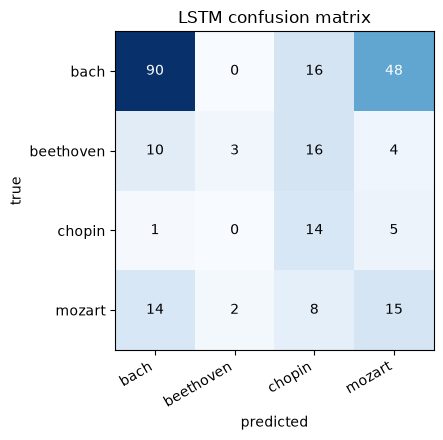

In [9]:
def plot_confusion(cm, title, path):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(4), yticks=range(4), xticklabels=COMPOSERS,
           yticklabels=COMPOSERS, xlabel="predicted", ylabel="true", title=title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    thresh = cm.max() / 2
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    fig.savefig(path, dpi=120)
    plt.show()


plot_confusion(metrics["confusion_matrix"], "LSTM confusion matrix",
               RESULTS_DIR / "confusion_lstm.png")

## Notes

- Only the first 500 note events of each piece are used, so the model is judging the opening, not the whole work. Windowing every piece into overlapping chunks and voting per piece is the obvious next lever if accuracy is short.
- Pitch is embedded rather than scaled — see the loading section for the underfitting the scaled version produced.
- Gradient clipping is required, not cosmetic — see the model section for the divergence without it.
- Class weights are computed from the pre-augmentation counts on purpose (see the cell above).
- Val/test keep the real composer distribution, so bach at 63% is the baseline to beat, not 25%.